# 05 — Phân phối dừng + xích hấp thụ + backtest (§4.4, §4.5)

Trạng thái: **FROZEN** (2026-09-23, full run 150.000 khoản vay — xem `.claude/skills/notebook-first-model-dev/SKILL.md`).

§4.4: phân phối dừng π (suy biến, chỉ minh họa lý thuyết) + dự báo hữu hạn kỳ μ_τ·P̂^t so với thực nghiệm. §4.5 (bắt buộc): N, B, PD_i(H=12) so với tỷ lệ Default/Prepaid **thực tế quan sát trên validation set**, theo từng trạng thái xuất phát tại τ.

In [1]:
%matplotlib inline

import os
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd())))

from utils.markov import (
    mle_transition_matrix,
    stationary_distribution,
    forecast_distribution,
    fundamental_matrix,
    absorption_probabilities,
    pd_finite_horizon,
)
from utils.transitions import build_pair_counts, pairs_to_count_matrix

In [ ]:
SUFFIX = "full"  # FROZEN o full; doi lai "smoke" chi de kiem tra nhanh, khong ghi de artifact chinh thuc

DATA_DIR = os.path.join("..", "data", "processed")
FIG_DIR = os.path.join("..", "outputs", "figures")
TABLE_DIR = os.path.join("..", "outputs", "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

STATE_NAMES = ["Current", "30 DPD", "60 DPD", "90+ DPD", "Default", "Prepaid"]
N_STATES = 6
ABSORBING = [4, 5]
TRANSIENT = [0, 1, 2, 3]
TAU = 24290  # month_index cua thang 202402, bien estimation/validation (Phase 1)
H = 12  # backtest horizon thang, Phuong an A da chot (khong dung H=24)
ALPHA = 0.05


def wilson_ci(x, n, alpha=ALPHA):
    """Khoang tin cay Wilson cho ty le quan sat x/n -- CI cho ty le thuc nghiem,
    KHONG phai bootstrap CI cho pi/B (ngoai pham vi, xem PROJECT_BRIEF.md muc 6)."""
    if n == 0:
        return (np.nan, np.nan)
    z = norm.ppf(1 - alpha / 2)
    p = x / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, center - margin), min(1.0, center + margin))

## 1. Load estimation set + validation set

In [3]:
est_df = pd.read_parquet(os.path.join(DATA_DIR, f"estimation_set_{SUFFIX}.parquet"))
val_df = pd.read_parquet(os.path.join(DATA_DIR, f"validation_set_{SUFFIX}.parquet"))
print(f"estimation_set: shape={est_df.shape}, month_index max={est_df['month_index'].max()} (kỳ vọng={TAU})")
print(f"validation_set: shape={val_df.shape}, month_index min={val_df['month_index'].min()}")

estimation_set: shape=(7253423, 6), month_index max=24290 (kỳ vọng=24290)
validation_set: shape=(986010, 6), month_index min=24291


## 2. Tính P_hat (estimation set)

In [4]:
pairs_1 = build_pair_counts(est_df, k=1)
n_ij = pairs_to_count_matrix(pairs_1, n_states=N_STATES)
P_hat = mle_transition_matrix(n_ij, absorbing_states=ABSORBING)
pd.DataFrame(P_hat, index=STATE_NAMES, columns=STATE_NAMES).round(4)

mle_transition_matrix: trạng thái [5] không có quan sát chuyển nào (hàng NaN)


,Current,30 DPD,60 DPD,90+ DPD,Default,Prepaid
Current,0.9798,0.0051,0.0000,0.0000,0.0000,0.0150
30 DPD,0.4293,0.3220,0.2289,0.0008,0.0001,0.0190
60 DPD,0.1505,0.0950,0.2266,0.5120,0.0005,0.0154
90+ DPD,0.1109,0.0128,0.0214,0.6517,0.1888,0.0144
Default,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
Prepaid,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000


## 3. Phân phối dừng π (minh họa tính suy biến lý thuyết)

In [5]:
pi = stationary_distribution(P_hat)
print("π:", np.round(pi, 4))
print("Kiểm tra πP=π:", np.allclose(pi @ P_hat, pi, atol=1e-6))
print("Kiểm tra Σπ=1:", np.isclose(pi.sum(), 1.0))
print("Ghi chú: nghiệm SUY BIẾN (xích có 2 trạng thái hấp thụ) -- đây là 1 trong vô số")
print("nghiệm thỏa πP=π, KHÔNG dùng để so trực tiếp với phân phối thực nghiệm (Ch.2 §2.4.4).")

π: [-0.  -0.  -0.  -0.   0.5  0.5]
Kiểm tra πP=π: True
Kiểm tra Σπ=1: True
Ghi chú: nghiệm SUY BIẾN (xích có 2 trạng thái hấp thụ) -- đây là 1 trong vô số
nghiệm thỏa πP=π, KHÔNG dùng để so trực tiếp với phân phối thực nghiệm (Ch.2 §2.4.4).


## 4. μ_τ và dự báo hữu hạn kỳ μ_τ·P̂^t so với thực nghiệm theo từng tháng

In [6]:
mu_tau_counts = est_df.loc[est_df["month_index"] == TAU, "state"].value_counts()
mu_tau = np.array([mu_tau_counts.get(i, 0) for i in range(N_STATES)], dtype=float)
mu_tau = mu_tau / mu_tau.sum()
print(f"Số khoản vay có quan sát tại τ: {int(mu_tau_counts.sum())}")
pd.Series(mu_tau, index=STATE_NAMES).round(4)

Số khoản vay có quan sát tại τ: 42677


Current    0.9184
30 DPD     0.0092
60 DPD     0.0020
90+ DPD    0.0016
Default    0.0640
Prepaid    0.0048
dtype: float64

In [7]:
months_ahead = sorted(val_df.loc[val_df["month_index"] > TAU, "month_index"].unique())

# QUAN TRONG: khong tinh % tren tap khoan vay CON DANG BAO CAO moi thang (mau so
# co dan do khoan Prepaid/Default hoan tat ngung bao cao) -- se khong khop mau so
# co dinh cua du bao (mu_tau*P^t luon bao toan khoi luong tren toan bo cohort goc).
# Thay vao do: theo dung 42.677 khoan trong cohort tai tau xuyen suot, forward-fill
# trang thai cuoi cung da biet cho khoan nao ngung bao cao (nhat quan voi gia dinh
# sticky absorbing -- coi nhu giu nguyen trang thai do "mai mai" sau khi ngung bao cao).
cohort_base = est_df.loc[est_df["month_index"] == TAU, ["loan_id", "month_index", "state"]]
n_cohort = len(cohort_base)
val_cohort = val_df.loc[val_df["loan_id"].isin(set(cohort_base["loan_id"])), ["loan_id", "month_index", "state"]]
combined = pd.concat([cohort_base, val_cohort], ignore_index=True)

wide = combined.pivot(index="loan_id", columns="month_index", values="state")
wide = wide.sort_index(axis=1).ffill(axis=1)
print(f"Cohort cố định: {n_cohort} khoản vay, theo dõi xuyên suốt {len(months_ahead)} tháng (forward-fill)")

rows = []
for m in months_ahead:
    t = int(m - TAU)
    forecast = forecast_distribution(mu_tau, P_hat, t)
    actual_counts = wide[m].value_counts()
    actual = np.array([actual_counts.get(i, 0) for i in range(N_STATES)], dtype=float) / n_cohort
    row = {"month_index": m, "t": t}
    for i, name in enumerate(STATE_NAMES):
        row[f"forecast_{name}"] = forecast[i]
        row[f"actual_{name}"] = actual[i]
    rows.append(row)

forecast_vs_actual = pd.DataFrame(rows)
forecast_vs_actual.to_csv(os.path.join(TABLE_DIR, "forecast_vs_actual_distribution.csv"), index=False)
forecast_vs_actual.head()

Cohort cố định: 42677 khoản vay, theo dõi xuyên suốt 25 tháng (forward-fill)


,month_index,t,forecast_Current,actual_Current,forecast_30 DPD,actual_30 DPD,forecast_60 DPD,actual_60 DPD,forecast_90+ DPD,actual_90+ DPD,forecast_Default,actual_Default,forecast_Prepaid,actual_Prepaid
0,24291,1,0.904252,0.913138,0.007894,0.009209,0.002605,0.001734,0.002090,0.001500,0.064305,0.064273,0.018853,0.010146
1,24292,2,0.889972,0.908077,0.007472,0.009045,0.002463,0.001640,0.002708,0.001382,0.064704,0.064508,0.032682,0.015348
2,24293,3,0.875846,0.904070,0.007257,0.007240,0.002347,0.001851,0.003038,0.001172,0.065219,0.064742,0.046294,0.020925
3,24294,4,0.861933,0.894557,0.007108,0.010638,0.002278,0.002085,0.003193,0.001382,0.065796,0.064906,0.059692,0.026431
4,24295,5,0.848244,0.890198,0.006984,0.008248,0.002231,0.002179,0.003259,0.001476,0.066402,0.065070,0.072880,0.032828


## 5. Biểu đồ so sánh dự báo vs thực tế theo thời gian

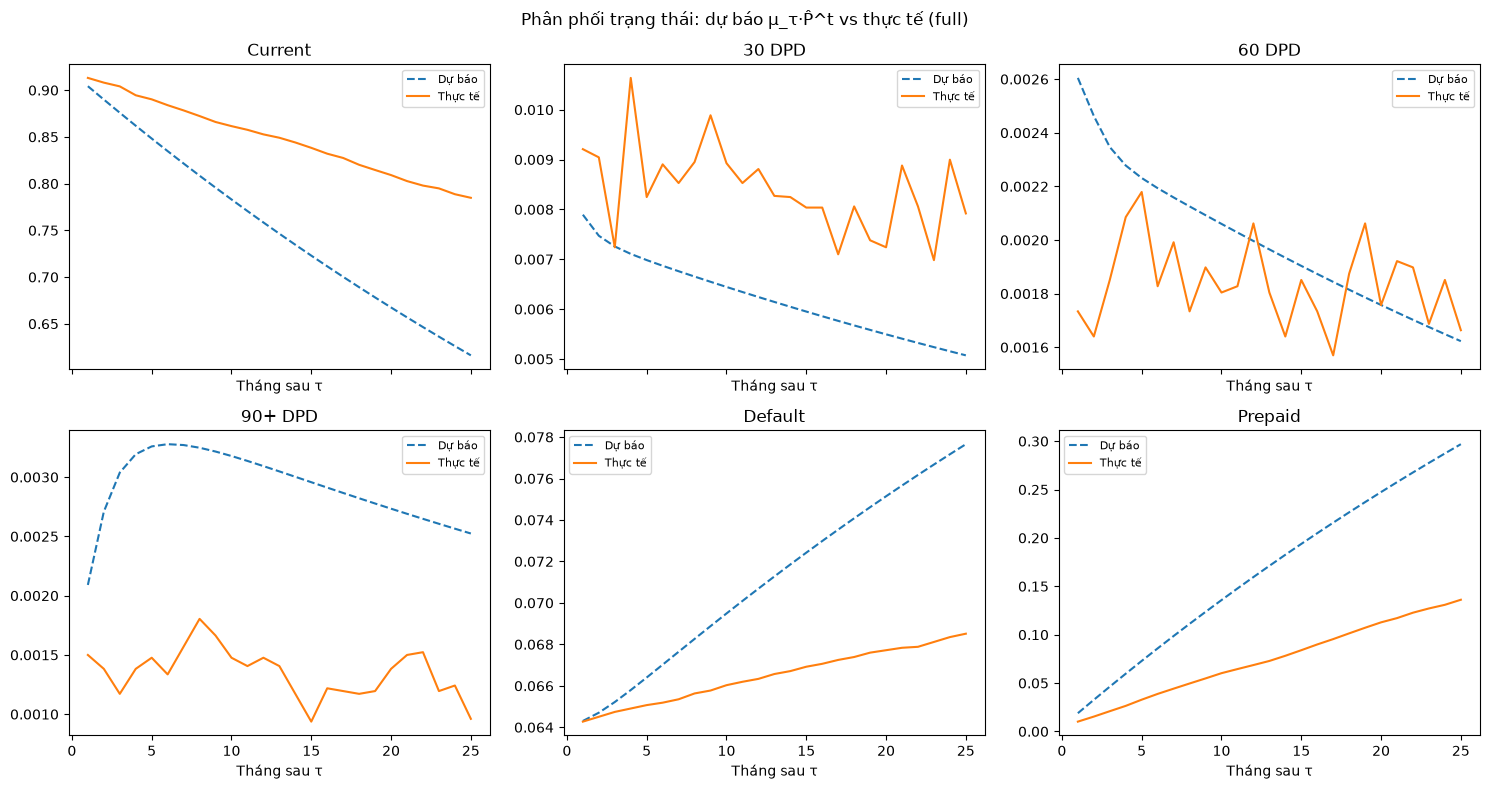

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, name in zip(axes.flat, STATE_NAMES):
    ax.plot(forecast_vs_actual["t"], forecast_vs_actual[f"forecast_{name}"], "--", label="Dự báo")
    ax.plot(forecast_vs_actual["t"], forecast_vs_actual[f"actual_{name}"], "-", label="Thực tế")
    ax.set_title(name)
    ax.set_xlabel("Tháng sau τ")
    ax.legend(fontsize=8)
fig.suptitle(f"Phân phối trạng thái: dự báo μ_τ·P̂^t vs thực tế ({SUFFIX})")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "forecast_vs_actual_distribution.png"), dpi=150)
display(fig)
plt.close(fig)

## 6. Tách Q, R; tính N, B (trọn đời)

In [9]:
Q = P_hat[:4, :4]
R = P_hat[:4, 4:6]
N = fundamental_matrix(Q)
B = absorption_probabilities(N, R)
print("N (thời gian kỳ vọng đến hấp thụ, từng cặp trạng thái):")
display(pd.DataFrame(N, index=STATE_NAMES[:4], columns=STATE_NAMES[:4]).round(4))
print("B (xác suất hấp thụ trọn đời, Default vs Prepaid):")
display(pd.DataFrame(B, index=STATE_NAMES[:4], columns=["Default", "Prepaid"]).round(4))

N (thời gian kỳ vọng đến hấp thụ, từng cặp trạng thái):


,Current,30 DPD,60 DPD,90+ DPD
Current,62.5008,0.5009,0.1565,0.2325
30 DPD,51.1636,1.9657,0.6081,0.8995
60 DPD,34.2545,0.5131,1.5072,2.2178
90+ DPD,23.8751,0.2630,0.1647,3.1146


B (xác suất hấp thụ trọn đời, Default vs Prepaid):


,Default,Prepaid
Current,0.0441,0.9559
30 DPD,0.1704,0.8296
60 DPD,0.4196,0.5804
90+ DPD,0.5883,0.4117


## 7. Tính PD_i(H=12)

In [10]:
pd_h = pd_finite_horizon(N, R, Q, H)
pd.DataFrame(pd_h, index=STATE_NAMES[:4], columns=["Default", "Prepaid"]).round(4)

,Default,Prepaid
Current,0.0041,0.1664
30 DPD,0.1318,0.1596
60 DPD,0.3889,0.1240
90+ DPD,0.5662,0.0931


## 8. Xác định cohort tại τ (state ∈ {0,1,2,3})

In [11]:
cohort = est_df.loc[(est_df["month_index"] == TAU) & (est_df["state"].isin(TRANSIENT)), ["loan_id", "state"]]
cohort = cohort.rename(columns={"state": "state_at_tau"})
print(f"Tổng cohort tại τ: {len(cohort)} khoản vay")
cohort["state_at_tau"].value_counts().sort_index()

Tổng cohort tại τ: 39741 khoản vay


state_at_tau
0    39195
1      392
2       84
3       70
Name: count, dtype: int64

## 9. Xác định outcome thực tế trong cửa sổ (τ, τ+H]

In [12]:
window = val_df[(val_df["month_index"] > TAU) & (val_df["month_index"] <= TAU + H)]
hit_default = window.groupby("loan_id")["state"].apply(lambda s: (s == 4).any())
hit_prepaid = window.groupby("loan_id")["state"].apply(lambda s: (s == 5).any())

cohort = cohort.set_index("loan_id")
cohort["hit_default"] = hit_default.reindex(cohort.index, fill_value=False)
cohort["hit_prepaid"] = hit_prepaid.reindex(cohort.index, fill_value=False)
cohort = cohort.reset_index()
cohort.groupby("state_at_tau")[["hit_default", "hit_prepaid"]].sum()

,hit_default,hit_prepaid
state_at_tau,,
0,34,2679
1,15,38
2,13,6
3,38,0


## 10-11. Tính DR_i(12), PR_i(12) + Wilson CI; bảng so sánh backtest

In [13]:
backtest_rows = []
for i in TRANSIENT:
    sub = cohort[cohort["state_at_tau"] == i]
    m_i = len(sub)
    x_default = int(sub["hit_default"].sum())
    x_prepaid = int(sub["hit_prepaid"].sum())
    dr = x_default / m_i if m_i > 0 else np.nan
    pr = x_prepaid / m_i if m_i > 0 else np.nan
    dr_lo, dr_hi = wilson_ci(x_default, m_i)
    pr_lo, pr_hi = wilson_ci(x_prepaid, m_i)
    backtest_rows.append({
        "state_i": STATE_NAMES[i],
        "m_i": m_i,
        "PD_i_pred": pd_h[i, 0],
        "DR_i_actual": dr,
        "DR_i_ci_low": dr_lo,
        "DR_i_ci_high": dr_hi,
        "PD_diff": pd_h[i, 0] - dr,
        "PR_i_pred": pd_h[i, 1],
        "PR_i_actual": pr,
        "PR_i_ci_low": pr_lo,
        "PR_i_ci_high": pr_hi,
        "PR_diff": pd_h[i, 1] - pr,
    })

backtest_table = pd.DataFrame(backtest_rows)
backtest_table.to_csv(os.path.join(TABLE_DIR, "backtest_4_5.csv"), index=False)
backtest_table.round(4)

,state_i,m_i,PD_i_pred,DR_i_actual,DR_i_ci_low,DR_i_ci_high,PD_diff,PR_i_pred,PR_i_actual,PR_i_ci_low,PR_i_ci_high,PR_diff
0,Current,39195,0.0041,0.0009,0.0006,0.0012,0.0033,0.1664,0.0684,0.0659,0.0709,0.0981
1,30 DPD,392,0.1318,0.0383,0.0233,0.0622,0.0935,0.1596,0.0969,0.0714,0.1303,0.0626
2,60 DPD,84,0.3889,0.1548,0.0927,0.2470,0.2342,0.1240,0.0714,0.0331,0.1472,0.0526
3,90+ DPD,70,0.5662,0.5429,0.4270,0.6543,0.0233,0.0931,0.0000,0.0000,0.0520,0.0931


## 12. Biểu đồ cột so sánh dự đoán vs thực tế

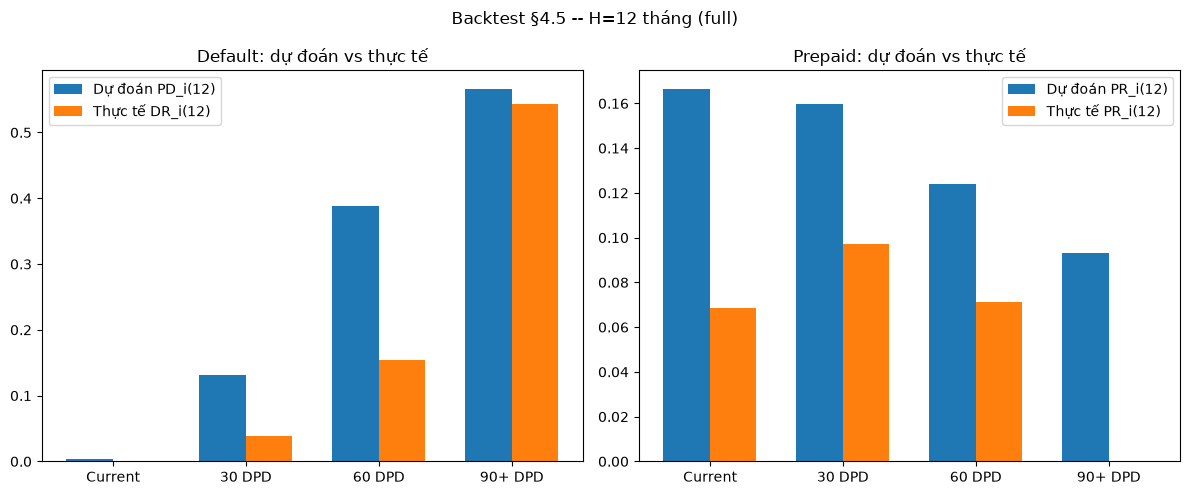

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(TRANSIENT))
width = 0.35

axes[0].bar(x - width / 2, backtest_table["PD_i_pred"], width, label="Dự đoán PD_i(12)")
axes[0].bar(x + width / 2, backtest_table["DR_i_actual"], width, label="Thực tế DR_i(12)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(backtest_table["state_i"])
axes[0].set_title("Default: dự đoán vs thực tế")
axes[0].legend()

axes[1].bar(x - width / 2, backtest_table["PR_i_pred"], width, label="Dự đoán PR_i(12)")
axes[1].bar(x + width / 2, backtest_table["PR_i_actual"], width, label="Thực tế PR_i(12)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(backtest_table["state_i"])
axes[1].set_title("Prepaid: dự đoán vs thực tế")
axes[1].legend()

fig.suptitle(f"Backtest §4.5 -- H={H} tháng ({SUFFIX})")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "backtest_4_5.png"), dpi=150)
display(fig)
plt.close(fig)

## 13. Quyết định

Quyết định: Chấp nhận kết quả §4.4 và §4.5 này làm kết luận chính thức. Không tinh chỉnh lại `P_hat` (ví dụ ước lượng trên cửa sổ gần τ hơn thay vì toàn bộ 2016-2024) dù đã cân nhắc hướng này — HUNG quyết định dừng ở kết quả hiện tại để không kéo dài thêm, ghi nhận hạn chế trung thực thay vì tiếp tục tinh chỉnh.

Lý do:

**§4.4 — có 1 lỗi phương pháp đã phát hiện và sửa trong quá trình REVIEWED:** bản DRAFT ban đầu tính "% thực tế" bằng cách chia cho số khoản **còn đang báo cáo** mỗi tháng — mẫu số này co dần (85,7% còn lại sau 25 tháng) vì khoản Prepaid/Default hoàn tất đều ngừng xuất hiện trong dữ liệu thô, khiến % Prepaid thực tế bị tính sai nghiêm trọng (0,61% thay vì đúng ra phải là 13,6%). Đã sửa bằng cách theo dõi cố định 42.677 khoản trong cohort tại τ xuyên suốt 25 tháng, forward-fill trạng thái cuối cùng đã biết cho khoản ngừng báo cáo (nhất quán với giả định sticky-absorbing). Sau khi sửa:
- Bậc thang quá hạn (30/60/90+DPD) và Default: dự báo khớp thực tế khá tốt trong suốt 25 tháng (lệch <1 điểm % ở Default, tăng dần rất chậm từ 0 lên 0,92 điểm %).
- Current và Prepaid lệch lớn và đối xứng nhau (Current: -16,86 điểm %; Prepaid: +16,08 điểm % ở t=25) — mô hình dự báo tốc độ trả trước hạn nhanh gấp hơn 2 lần thực tế. Nguyên nhân: `P_hat` học từ estimation set gộp cả giai đoạn lãi suất thấp 2020-2021 (làn sóng refinance), áp lên giai đoạn validation 2024-2026 lãi suất cao hơn — khớp trực tiếp với kết quả bác bỏ tính thuần nhất theo thời gian ở §4.2.

**§4.5 — backtest bắt buộc (không có lỗi phương pháp, logic theo window độc lập với bug ở §4.4):**
- Default: mô hình dự đoán cao hơn thực tế ở Current/30DPD/60DPD (lệch có ý nghĩa thống kê, nằm ngoài CI Wilson của thực tế) — tệ nhất ở 60DPD (dự đoán 38,9% vs thực tế 15,5%, m=84). Nhưng tại **90+DPD** (trạng thái quan trọng nhất cho cảnh báo sớm), dự đoán 56,6% nằm **trong** CI thực tế [42,7%-65,4%] (m=70, CI khá rộng do cỡ mẫu nhỏ) — không phân biệt được về thống kê, đây là điểm sáng của mô hình.
- Prepaid: mô hình dự đoán cao hơn thực tế ở mọi trạng thái xuất phát, cực đoan nhất ở 90+DPD (dự đoán 9,3% vs thực tế 0/70 khoản) — hợp lý về kinh tế (khoản quá hạn nặng hiếm khi đủ điều kiện refinance).
- Kết luận chung: mô hình hệ thống hóa việc dự đoán rủi ro (Default lẫn Prepaid) cao hơn thực tế cho phần lớn cohort, nhất quán với vi phạm thuần nhất đã phát hiện ở §4.2 — nhưng vẫn có giá trị thực tiễn ở đúng nhóm quan trọng nhất (90+DPD, gần vỡ nợ nhất).

**Không tiếp tục tinh chỉnh** (ví dụ ước lượng `P_hat` trên cửa sổ ngắn hơn/gần τ hơn) — đã cân nhắc và loại vì tốn thêm thời gian ngoài phạm vi ~6 buổi; ghi nhận đây là hạn chế thật của mô hình trong Ch.5 Kết luận thay vì tiếp tục điều chỉnh.